# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

# The data in question provide information related to 17 marketing campaigns

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import time



In [2]:
raw_df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



# 3.1. Get the list of numerical and categorical features

In [4]:
num_features=raw_df.select_dtypes(include=['number']).columns.tolist()
cat_features=raw_df.select_dtypes(exclude=['number']).columns.tolist()
num_features
cat_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

# 3.2.  Check missing values

In [5]:
raw_df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

# 3.3. Balanced or Unbalanced dataset

In [6]:
raw_df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

The dataset is unbalanced. 

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [7]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

# Business objective
From the dataset, 88% is the rate of clients declining the bank's offers. From marketing policy, this rate is a major indicator of inefficient 
marketing policies and justifies the need of machine learning analysis for:  
  1. Figure out features contributing more to clients acceptance.  
  2. Figure out common characteristics of clients declining the bank's offers.  
  3. Improve clients' acceptance rate.  
  4. Reduce the cost by targeting clients with high propability of accepting offers.  
  5. Focus bank's resource(personal, calls, time, money  ..) on targeted clients.  
  6. Imrpove the bank marketing policy by analyzing characteristics of client declining offers for future policy improvement and financial investment.  

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

## 5.1 Correlation Matrix
Applicable on numerical features

In [8]:
num_features=raw_df.select_dtypes(include=['number']).columns.tolist()
num_features

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

<Axes: >

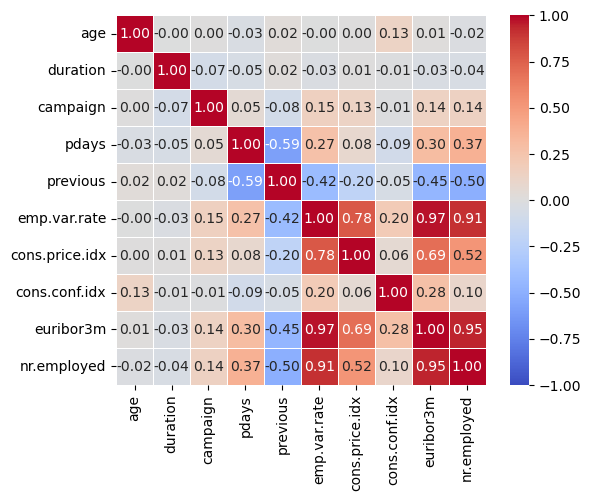

In [9]:
corr_matrix=raw_df[num_features].corr()
#plt.imshow(corr_matrix,cmap='hot',interpolation='nearest')
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",vmin=-1,vmax=1,center=0,fmt=".2f",square=True,linewidths=0.5, )

From the heatmap above, we notice strong correlation  between these pairs of attributes:  
(nr.employed , euribor3m) , (nr.employed , emp.var.rate), (euribor3m , emp.var.rate)   
This is a multicollinearity case that might result in(source google AI):  
    1. Unstable model: Small changes in the data can cause wild swings in regression coefficient values.  
    2. High standard errors: P-values become unreliable, making statistically significant variables look insignificant.  
    3. Hard to interpret: impossible to isolate the individual effect of each predictor variable on the dependant feature.  

We will delete euribor3m and emp.var.rate features.   


In [10]:
# Delete euribor3m and emp.var.rate features, save data onto clean_df dataframe
clean_df=raw_df.drop(columns=['euribor3m','emp.var.rate'])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [11]:
# Define features (X) and target (y)
X = clean_df.drop('y', axis=1)
y = clean_df['y']


In [12]:
# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)
    ]
)

In [13]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

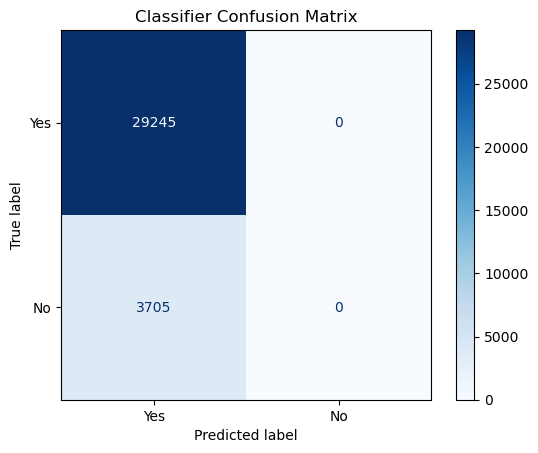

0.8865015780529255

In [14]:
dummy_clf = ''
baseline_score = ''
   

dummy_clf = DummyClassifier().fit(X_train, y_train)
baseline_score = dummy_clf.score(X_test, y_test)


#  Generate the confusion matrix array
y_pred=dummy_clf.predict(X_train)
cm = confusion_matrix(y_train, y_pred)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Yes', 'No'])
disp.plot(cmap=plt.cm.Blues)

# Show the plot
plt.title("Classifier Confusion Matrix")
plt.show()

baseline_score


## The baseline accuracy is 0.88

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [15]:
# Create LogisticRegression model
lg_model=LogisticRegression()
# Create a pipeline
pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', lg_model)
    ])
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Problem 9: Score the Model

What is the accuracy of your model?

In [16]:
lg_score=pipeline.score(X_test,y_test)
lg_score

0.911143481427531

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [17]:
# Define the models and hyperparameters
models = {
    'knn': KNeighborsClassifier(),
    'logisticregression': LogisticRegression(max_iter=1000),
    'svc': SVC(),
    'decisiontreeclassifier': DecisionTreeClassifier()
}

In [18]:
results = []

for name, model in models.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
       
    # Fit the model and time it
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = (time.time() - start_time) 
        
    # Evaluate on training and test sets
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    
    # Append the results
    results.append([name, train_score, test_score, fit_time])

# Create the results DataFrame
results_df = pd.DataFrame(results, columns=['model', 'train score', 'test score', 'average fit time'])
results_df.set_index('model', inplace=True)


results_df

,train score,test score,average fit time
model,,,
knn,0.928498,0.902525,0.139558
logisticregression,0.910744,0.911143,0.264608
svc,0.923156,0.911508,25.984989
decisiontreeclassifier,1.000000,0.886866,0.931018


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [19]:
# Define the models and hyperparameters
models = {
    'knn': (KNeighborsClassifier(), {'knn__n_neighbors': [3, 5, 7]}),
    'logisticregression': (LogisticRegression(max_iter=1000), {'logisticregression__C': [0.1, 1, 10]}),
    'svc': (SVC(), {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']}),
    'decisiontreeclassifier': (DecisionTreeClassifier(), {'decisiontreeclassifier__max_depth': [5, 10, 15]})
}

In [20]:
results = []
best_models=[]

for name, (model, params) in models.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1,scoring='accuracy')
    
    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_model = grid_search.best_estimator_
    best_models.append(best_model)
    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    
    # Append the results
    results.append([name, train_score, test_score, fit_time])

# Create the results DataFrame
results_df = pd.DataFrame(results, columns=['model', 'train score', 'test score', 'average fit time'])
results_df.set_index('model', inplace=True)



In [21]:

results_df

,train score,test score,average fit time
model,,,
knn,0.923794,0.904224,29.790448
logisticregression,0.910926,0.911022,0.569388
svc,0.923156,0.911508,76.831335
decisiontreeclassifier,0.916449,0.914178,0.746265


# Models' performances 
svc has best train score and test score  
decisiontreeclassifier has the best fitting time as decision boundaries are hard coded  

11.1. Let's now provides details on SVC classifier

In [22]:
svc_model=best_models[2]

In [23]:
svc_model

,steps,"[('preprocessor', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
print(classification_report(y_test,svc_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



Using SVC model, we are not able to determine which features have more impact on the regression model

11.2. Examine DecitionTreeModel 

In [25]:
dtm_model=svc_model=best_models[3]
dtm_model

,steps,"[('preprocessor', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
dtm_model[name]
# Export and print the text representation
features = dtm_model.named_steps["preprocessor"].get_feature_names_out()
tree = export_text(dtm_model[name],feature_names=features)
print(tree)

|--- num__nr.employed <= -1.10
|   |--- num__duration <= -0.36
|   |   |--- num__pdays <= -5.13
|   |   |   |--- cat__day_of_week_mon <= 0.50
|   |   |   |   |--- num__duration <= -0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__duration >  -0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- cat__day_of_week_mon >  0.50
|   |   |   |   |--- num__duration <= -0.38
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__duration >  -0.38
|   |   |   |   |   |--- class: 1
|   |   |--- num__pdays >  -5.13
|   |   |   |--- num__duration <= -0.52
|   |   |   |   |--- num__duration <= -0.69
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__duration >  -0.69
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__duration >  -0.52
|   |   |   |   |--- num__cons.price.idx <= 0.65
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__cons.price.idx >  0.65
|   |   |   |   |   |--- class: 0
|   |--- num__duration >  -0.36
|   |   |--- num__pdays <= -5.09


##### Questions

## From the above Decision Tree Classifiers with depth 5, The accuracy is obtained by using 5 feautres:  
nr_employed    
duration    
pdays    
day_oftheweek  
contact  
